<a href="https://colab.research.google.com/github/salianvikram/VTU-MAJOR-PROJECT-27/blob/main/RFMODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.


/tmp/ipykernel_1650/105962659.py:36: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name)



Dataset loaded successfully.
Dataset Shape: (1048575, 16)

First 5 rows:
  StationId          Datetime  PM2.5    PM10    NO    NO2    NOx    NH3   CO  \
0     AP001  24-11-2017 17:00  60.50   98.00  2.35  30.80  18.25   8.50  0.1   
1     AP001  24-11-2017 18:00  65.50  111.25  2.70  24.20  15.07   9.77  0.1   
2     AP001  24-11-2017 19:00  80.00  132.00  2.10  25.18  15.15  12.02  0.1   
3     AP001  24-11-2017 20:00  81.50  133.25  1.95  16.25  10.23  11.58  0.1   
4     AP001  24-11-2017 21:00  75.25  116.00  1.43  17.48  10.43  12.03  0.1   

     SO2      O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  11.85  126.40      0.1     6.10    0.10  NaN        NaN  
1  13.17  117.12      0.1     6.25    0.15  NaN        NaN  
2  12.08   98.98      0.2     5.98    0.18  NaN        NaN  
3  10.47  112.20      0.2     6.72    0.10  NaN        NaN  
4   9.12  106.35      0.2     5.75    0.08  NaN        NaN  

Columns available:
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NO

/tmp/ipykernel_1650/105962659.py:234: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rolling_3'] = (
/tmp/ipykernel_1650/105962659.py:245: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rolling_6'] = (
/tmp/ipykernel_1650/105962659.py:256: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy(


Rolling pollutant features created.


/tmp/ipykernel_1650/105962659.py:274: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AQI_rolling_3'] = (
/tmp/ipykernel_1650/105962659.py:284: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AQI_rolling_6'] = (
/tmp/ipykernel_1650/105962659.py:294: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d


Rolling AQI features created.

Next-hour AQI target created.

Total number of features: 130


/tmp/ipykernel_1650/105962659.py:314: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AQI_Next_Hour'] = (



Rows available for modelling: 28378

Training rows: 19157
Testing rows: 9221

X_train shape: (19157, 130)
X_test shape: (9221, 130)

Training Random Forest...

Random Forest training completed.

Test predictions generated.


MODEL 3 PERFORMANCE
MAE  : 5.09
MSE  : 96.05
RMSE : 9.80
R²   : 0.9845


TOP 20 MOST IMPORTANT FEATURES
              Feature  Importance
86          AQI_lag_1    0.991386
93   PM2.5_rolling_24    0.001152
0               PM2.5    0.000794
30       PM2.5_lag_24    0.000653
8                  O3    0.000587
6                  CO    0.000438
1                PM10    0.000262
96    PM10_rolling_24    0.000260
88          AQI_lag_6    0.000226
35        PM10_lag_24    0.000208
26        PM2.5_lag_1    0.000151
89         AQI_lag_12    0.000138
87          AQI_lag_3    0.000136
92    PM2.5_rolling_6    0.000110
129    AQI_rolling_24    0.000106
128     AQI_rolling_6    0.000099
95     PM10_rolling_6    0.000080
105    NOx_rolling_24    0.000071
111     CO_rolling_24   

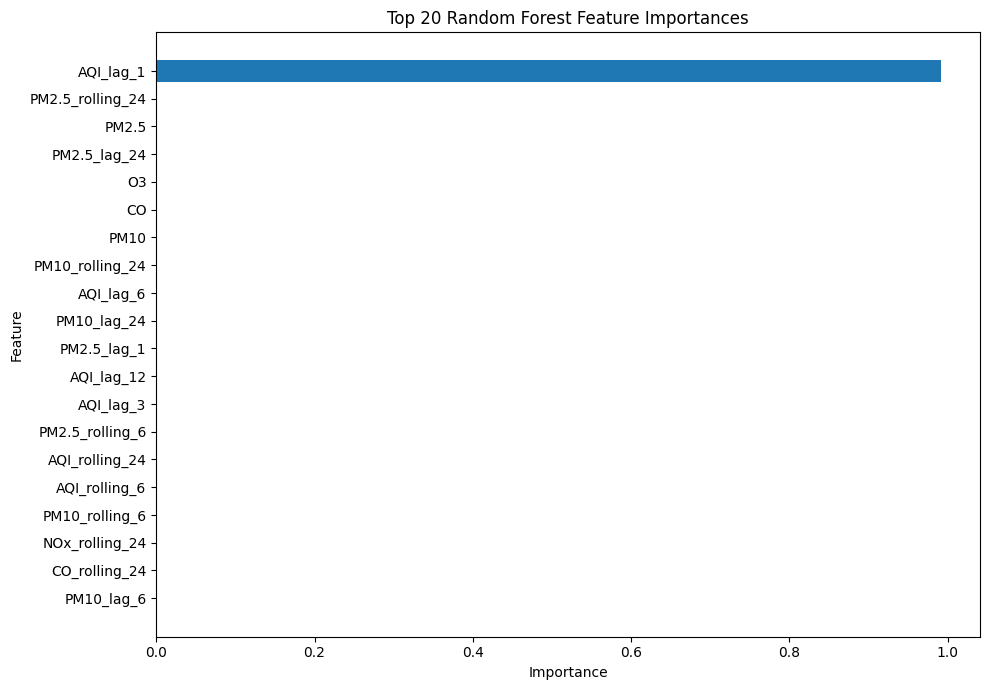

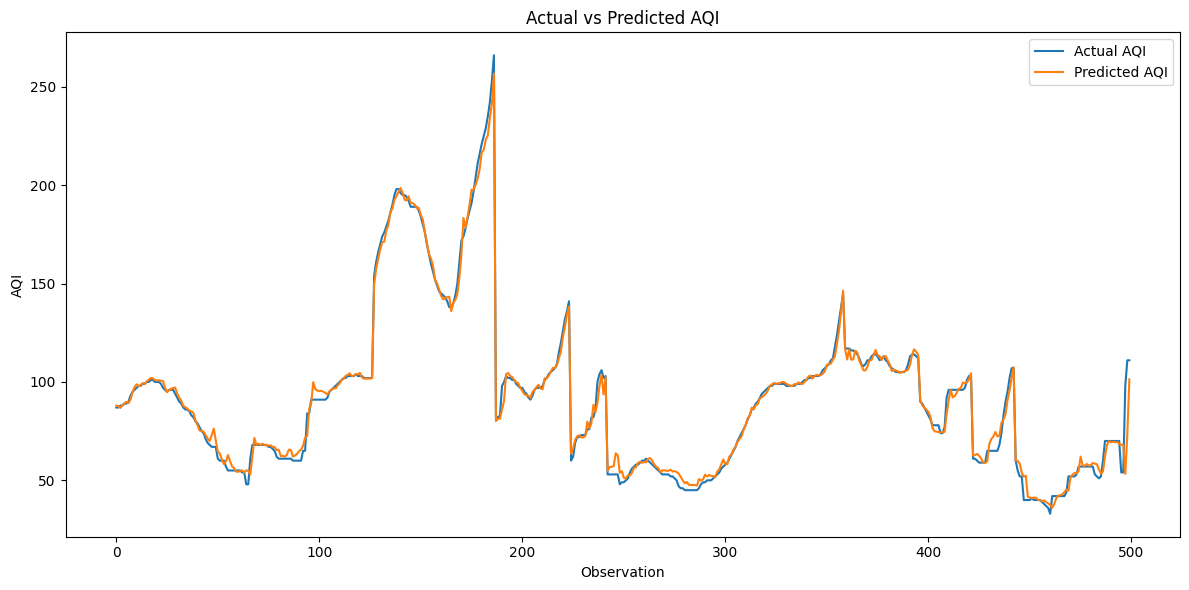


Model saved as AQI_RandomForest_Model3.pkl


FINAL MODEL 3 SUMMARY
Algorithm        : Random Forest Regressor
Prediction        : Next-Hour AQI
Pollutants        : All available pollutants
Lag periods       : 1, 3, 6, 12, 24 hours
Rolling periods   : 3, 6, 24 hours
Training period   : 2015 - 2019
Testing period    : 2020
MAE               : 5.09
RMSE              : 9.80
R²                : 0.9845


In [ ]:
# ============================================================
# AIR QUALITY INDEX (AQI) PREDICTION
# MODEL 3
# RANDOM FOREST + ALL POLLUTANTS + LAG + ROLLING FEATURES
# NEXT-HOUR AQI FORECASTING
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")


# ============================================================
# 2. LOAD DATASET
# ============================================================

# Dataset is already available in Colab

file_name = "station_hour.csv"

df = pd.read_csv(file_name)

print("\nDataset loaded successfully.")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("\nColumns available:")
print(df.columns.tolist())


# ============================================================
# 4. CONVERT DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(
    df['Datetime'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

df = df.dropna(
    subset=['Datetime']
)

print("\nDatetime conversion completed.")


# ============================================================
# 5. SORT DATA CHRONOLOGICALLY
# ============================================================

df = df.sort_values(
    by=['StationId', 'Datetime']
).reset_index(drop=True)

print("\nDataset sorted by StationId and Datetime.")


# ============================================================
# 6. DEFINE POLLUTANT FEATURES
# ============================================================

pollutant_features = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'
]

# Keep only columns that exist

pollutant_features = [
    col for col in pollutant_features
    if col in df.columns
]

print("\nPollutant features used:")
print(pollutant_features)


# ============================================================
# 7. CONVERT POLLUTANTS AND AQI TO NUMERIC
# ============================================================

for col in pollutant_features:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )


df['AQI'] = pd.to_numeric(
    df['AQI'],
    errors='coerce'
)

print("\nPollutant and AQI columns converted to numeric.")


# ============================================================
# 8. CREATE TIME FEATURES
# ============================================================

df['Hour'] = df['Datetime'].dt.hour

df['Day'] = df['Datetime'].dt.day

df['Month'] = df['Datetime'].dt.month

df['DayOfWeek'] = df['Datetime'].dt.dayofweek

df['DayOfYear'] = df['Datetime'].dt.dayofyear

df['WeekOfYear'] = (
    df['Datetime']
    .dt.isocalendar()
    .week
    .astype(int)
)

df['Year'] = df['Datetime'].dt.year

df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

print("\nTime features created.")


# ============================================================
# 9. CREATE CYCLIC TIME FEATURES
# ============================================================

df['Hour_Sin'] = np.sin(
    2 * np.pi * df['Hour'] / 24
)

df['Hour_Cos'] = np.cos(
    2 * np.pi * df['Hour'] / 24
)

df['Month_Sin'] = np.sin(
    2 * np.pi * df['Month'] / 12
)

df['Month_Cos'] = np.cos(
    2 * np.pi * df['Month'] / 12
)

df['DayOfWeek_Sin'] = np.sin(
    2 * np.pi * df['DayOfWeek'] / 7
)

df['DayOfWeek_Cos'] = np.cos(
    2 * np.pi * df['DayOfWeek'] / 7
)

print("\nCyclic time features created.")


# ============================================================
# 10. CREATE POLLUTANT LAG FEATURES
# ============================================================

lag_hours = [1, 3, 6, 12, 24]

for col in pollutant_features:

    for lag in lag_hours:

        df[f'{col}_lag_{lag}'] = (
            df.groupby('StationId')[col]
            .shift(lag)
        )

print("\nPollutant lag features created.")


# ============================================================
# 11. CREATE AQI LAG FEATURES
# ============================================================

for lag in lag_hours:

    df[f'AQI_lag_{lag}'] = (
        df.groupby('StationId')['AQI']
        .shift(lag)
    )

print("\nAQI lag features created.")


# ============================================================
# 12. CREATE ROLLING POLLUTANT FEATURES
# ============================================================

for col in pollutant_features:

    # Previous 3-hour average
    df[f'{col}_rolling_3'] = (
        df.groupby('StationId')[col]
        .transform(
            lambda x:
            x.shift(1)
            .rolling(3)
            .mean()
        )
    )

    # Previous 6-hour average
    df[f'{col}_rolling_6'] = (
        df.groupby('StationId')[col]
        .transform(
            lambda x:
            x.shift(1)
            .rolling(6)
            .mean()
        )
    )

    # Previous 24-hour average
    df[f'{col}_rolling_24'] = (
        df.groupby('StationId')[col]
        .transform(
            lambda x:
            x.shift(1)
            .rolling(24)
            .mean()
        )
    )


print("\nRolling pollutant features created.")


# ============================================================
# 13. CREATE ROLLING AQI FEATURES
# ============================================================

df['AQI_rolling_3'] = (
    df.groupby('StationId')['AQI']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(3)
        .mean()
    )
)

df['AQI_rolling_6'] = (
    df.groupby('StationId')['AQI']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(6)
        .mean()
    )
)

df['AQI_rolling_24'] = (
    df.groupby('StationId')['AQI']
    .transform(
        lambda x:
        x.shift(1)
        .rolling(24)
        .mean()
    )
)

print("\nRolling AQI features created.")


# ============================================================
# 14. CREATE NEXT-HOUR AQI TARGET
# ============================================================

# Current time = t
# Target = AQI at t + 1 hour

df['AQI_Next_Hour'] = (
    df.groupby('StationId')['AQI']
    .shift(-1)
)

print("\nNext-hour AQI target created.")


# ============================================================
# 15. DEFINE TIME FEATURES
# ============================================================

time_features = [

    'Hour',
    'Day',
    'Month',
    'DayOfWeek',
    'DayOfYear',
    'WeekOfYear',
    'Year',
    'IsWeekend',

    'Hour_Sin',
    'Hour_Cos',

    'Month_Sin',
    'Month_Cos',

    'DayOfWeek_Sin',
    'DayOfWeek_Cos'
]


# ============================================================
# 16. DEFINE LAG FEATURES
# ============================================================

lag_features = []

for col in pollutant_features:

    for lag in lag_hours:

        lag_features.append(
            f'{col}_lag_{lag}'
        )


# ============================================================
# 17. DEFINE AQI LAG FEATURES
# ============================================================

aqi_lag_features = [

    f'AQI_lag_{lag}'

    for lag in lag_hours

]


# ============================================================
# 18. DEFINE ROLLING FEATURES
# ============================================================

rolling_features = []

for col in pollutant_features:

    rolling_features.extend([

        f'{col}_rolling_3',

        f'{col}_rolling_6',

        f'{col}_rolling_24'

    ])


# ============================================================
# 19. DEFINE AQI ROLLING FEATURES
# ============================================================

aqi_rolling_features = [

    'AQI_rolling_3',
    'AQI_rolling_6',
    'AQI_rolling_24'

]


# ============================================================
# 20. COMBINE ALL FEATURES
# ============================================================

features = (

    pollutant_features

    + time_features

    + lag_features

    + aqi_lag_features

    + rolling_features

    + aqi_rolling_features

)

print("\nTotal number of features:", len(features))


# ============================================================
# 21. REMOVE MISSING VALUES
# ============================================================

df_model = df.dropna(
    subset=features + ['AQI_Next_Hour']
).copy()

print(
    "\nRows available for modelling:",
    len(df_model)
)


# ============================================================
# 22. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# TRAINING DATA:
# 2015 - 2019
#
# TEST DATA:
# 2020

train_df = df_model[
    df_model['Year'] < 2020
].copy()

test_df = df_model[
    df_model['Year'] >= 2020
].copy()

print("\nTraining rows:", len(train_df))

print("Testing rows:", len(test_df))


# ============================================================
# 23. CREATE TRAINING DATA
# ============================================================

X_train = train_df[features]

y_train = train_df['AQI_Next_Hour']


# ============================================================
# 24. CREATE TESTING DATA
# ============================================================

X_test = test_df[features]

y_test = test_df['AQI_Next_Hour']


print("\nX_train shape:", X_train.shape)

print("X_test shape:", X_test.shape)


# ============================================================
# 25. TRAIN RANDOM FOREST
# ============================================================

print("\nTraining Random Forest...")

model = RandomForestRegressor(

    n_estimators=100,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=1,

    random_state=42,

    n_jobs=-1

)

model.fit(
    X_train,
    y_train
)

print("\nRandom Forest training completed.")


# ============================================================
# 26. PREDICT TEST DATA
# ============================================================

y_pred = model.predict(
    X_test
)

print("\nTest predictions generated.")


# ============================================================
# 27. CALCULATE MAE
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)


# ============================================================
# 28. CALCULATE MSE
# ============================================================

mse = mean_squared_error(
    y_test,
    y_pred
)


# ============================================================
# 29. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(mse)


# ============================================================
# 30. CALCULATE R²
# ============================================================

r2 = r2_score(
    y_test,
    y_pred
)


# ============================================================
# 31. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n")
print("=" * 60)
print("MODEL 3 PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

print("=" * 60)


# ============================================================
# 32. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    'Feature': features,

    'Importance': model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)


# ============================================================
# 33. DISPLAY TOP 20 FEATURES
# ============================================================

print("\n")
print("=" * 60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("=" * 60)

print(
    feature_importance.head(20)
)


# ============================================================
# 34. PLOT FEATURE IMPORTANCE
# ============================================================

top_features = feature_importance.head(20)

plt.figure(
    figsize=(10, 7)
)

plt.barh(

    top_features['Feature'][::-1],

    top_features['Importance'][::-1]

)

plt.xlabel(
    'Importance'
)

plt.ylabel(
    'Feature'
)

plt.title(
    'Top 20 Random Forest Feature Importances'
)

plt.tight_layout()

plt.show()


# ============================================================
# 35. ACTUAL VS PREDICTED AQI
# ============================================================

sample_size = min(
    500,
    len(y_test)
)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    y_test.iloc[:sample_size].values,
    label='Actual AQI'
)

plt.plot(
    y_pred[:sample_size],
    label='Predicted AQI'
)

plt.xlabel(
    'Observation'
)

plt.ylabel(
    'AQI'
)

plt.title(
    'Actual vs Predicted AQI'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 36. SAVE MODEL
# ============================================================

model_data = {

    'model': model,

    'features': features,

    'pollutant_features': pollutant_features

}

joblib.dump(

    model_data,

    'AQI_RandomForest_Model3.pkl'

)

print(
    "\nModel saved as AQI_RandomForest_Model3.pkl"
)


# ============================================================
# 37. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("FINAL MODEL 3 SUMMARY")
print("=" * 60)

print(
    "Algorithm        : Random Forest Regressor"
)

print(
    "Prediction        : Next-Hour AQI"
)

print(
    "Pollutants        : All available pollutants"
)

print(
    "Lag periods       : 1, 3, 6, 12, 24 hours"
)

print(
    "Rolling periods   : 3, 6, 24 hours"
)

print(
    "Training period   : 2015 - 2019"
)

print(
    "Testing period    : 2020"
)

print(
    f"MAE               : {mae:.2f}"
)

print(
    f"RMSE              : {rmse:.2f}"
)

print(
    f"R²                : {r2:.4f}"
)

print("=" * 60)